In [1]:
import sys
print("Python executable:", sys.executable)

Python executable: /home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/bin/python


In [2]:
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import cv2
#from utils import get_label_mask, set_class_values
import ast
import matplotlib.pyplot as plt

MODEL0_PATH = "nvidia/segformer-b0-finetuned-ade-512-512"
MODEL1_PATH = "nvidia/segformer-b1-finetuned-ade-512-512"
MODEL2_PATH = "nvidia/mit-b2"#"nvidia/segformer-b2-finetuned-ade-512-512"
MODEL3_PATH = "nvidia/segformer-b3-finetuned-ade-512-512"
MODEL4_PATH = "nvidia/segformer-b4-finetuned-ade-512-512"
MODEL5_PATH = "nvidia/segformer-b5-finetuned-ade-512-512"


class SemanticSegmentationDataset(Dataset):
    """Image (semantic) segmentation dataset."""

    def __init__(self, images_dir, masks_dir, feature_extractor):
        self.images_dir = images_dir
        self.class_values = []
        self.masks_dir = masks_dir
        self.feature_extractor = feature_extractor
        self.classes_file = 'full_classes.txt'
        self.color_file =  'colors.txt'
        self.label_colors_list = []
                
        with open(self.classes_file, 'r') as fid:
            data = [i.strip().split(':') for i in fid.readlines()]

        with open(self.color_file, 'r') as f:
            self.label_colors_list = [list(ast.literal_eval(line.strip())) for line in f if line.strip()]
        
        self.class_values = [int(i[0]) for i in data]
        #print(self.class_values)
        
        self.id2label = {int(x[0]):x[1] for x in data}
        image_file_names = [f for f in os.listdir(self.images_dir) if '.jpg' in f]
        mask_file_names = [f for f in os.listdir(self.masks_dir) if '.png' in f]
        
        self.images = sorted(image_file_names)
        self.masks = sorted(mask_file_names)
    
    def __len__(self):
        return len(self.images)

    def get_label_mask(self, mask, class_values, label_colors_list):
        label_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)
        #print('print something')
        for value in class_values:
            for ii, label in enumerate(label_colors_list):
                #print(f'value: {value}, label_colors_list: {label_colors_list.index(label)}')
                if value == label_colors_list.index(label):
                    label = np.array(label)
                    #print(sum(np.where(np.all(mask == label, axis=-1))[:2][0]))
                    label_mask[np.where(np.all(mask == label, axis=-1))[:2]] = value
        label_mask = label_mask.astype(int)
        return label_mask

    def __getitem__(self, idx):
        full_img_path = os.path.join(self.images_dir, self.images[idx])
        full_mask_path = os.path.join(self.masks_dir, self.masks[idx])
        
        image = cv2.imread(full_img_path)#, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype('float32')

        mask = cv2.imread(full_mask_path)#, cv2.IMREAD_COLOR)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB).astype('float32')

        #print(mask)
        #Скорее всего здесь проблема. Пофиксил вроде
        mask = self.get_label_mask(mask, self.class_values, self.label_colors_list).astype('uint8')
        #print('get_label_mask finished')
        mask_sum = sum([j for i in mask for j in i])
        #print(mask_sum, mask.shape)#Тут должно быть не 0

        image_pil = Image.fromarray(image.astype('uint8'))
        mask_pil = Image.fromarray(mask.astype('uint8'))
               
        encoded_inputs = self.feature_extractor(
            image_pil, 
            mask_pil,
            return_tensors='pt'
        )
        
        for k,v in encoded_inputs.items():
          encoded_inputs[k].squeeze_()

        return encoded_inputs

In [3]:
from transformers import SegformerFeatureExtractor
feature_extractor = SegformerFeatureExtractor.from_pretrained(MODEL2_PATH)
                                                            #"segformer-b0-finetuned-ade-512-512",
                                                             #local_files_only=True)                                                           
feature_extractor.reduce_labels = False #ПЕРЕПРОВЕРЬ
feature_extractor.size = 640

train_dataset = SemanticSegmentationDataset("car_dataset/images/train", "car_dataset/annotations/train_masks_rgb", feature_extractor)
val_dataset = SemanticSegmentationDataset("car_dataset/images/val", "car_dataset/annotations/val_masks_rgb", feature_extractor)
test_dataset = SemanticSegmentationDataset("car_dataset/images/test", "car_dataset/annotations/test_masks_rgb", feature_extractor)

batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3, prefetch_factor=8)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, num_workers=3, prefetch_factor=8)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=3, prefetch_factor=8)


/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/transformers/models/segformer/feature_extraction_segformer.py:35: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  super().__init__(*args, **kwargs)


In [4]:
import pytorch_lightning as pl
from transformers import SegformerForSemanticSegmentation
#from datasets import load_metric
import evaluate

import torch
from torch import nn

import numpy as np

class SegformerFinetuner(pl.LightningModule):
    
    def __init__(self, id2label, train_dataloader=None, val_dataloader=None, test_dataloader=None, metrics_interval=2):
        super(SegformerFinetuner, self).__init__()
        self.id2label = id2label
        self.metrics_interval = metrics_interval
        self.train_dl = train_dataloader
        self.val_dl = val_dataloader
        self.test_dl = test_dataloader
        
        self.num_classes = len(id2label.keys())
        self.label2id = {v:k for k,v in self.id2label.items()}

        self.validation_step_outputs = []
        self.test_step_outputs = []
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            MODEL2_PATH, 
            #"segformer-b0-finetuned-ade-512-512",
            #local_files_only=True,
            return_dict=False, 
            num_labels=self.num_classes,
            id2label=self.id2label,
            label2id=self.label2id,
            ignore_mismatched_sizes=True,
        )
        
        self.train_mean_iou = evaluate.load("mean_iou")
        self.val_mean_iou = evaluate.load("mean_iou")
        self.test_mean_iou = evaluate.load("mean_iou")

    def forward(self, images, masks=None):
        outputs = self.model(pixel_values=images, labels=masks)
        return(outputs)
    
    def training_step(self, batch, batch_nb):
        
        images, masks = batch['pixel_values'], batch['labels']
        
        outputs = self(images, masks)
        
        loss, logits = outputs[0], outputs[1]
        
        upsampled_logits = nn.functional.interpolate(
            logits, 
            size=masks.shape[-2:], 
            mode="bilinear", 
            align_corners=False
        )

        predicted = upsampled_logits.argmax(dim=1)

        self.train_mean_iou.add_batch(
            predictions=predicted.detach().cpu().numpy(), 
            references=masks.detach().cpu().numpy()
        )
        if batch_nb % self.metrics_interval == 0:

            metrics = self.train_mean_iou.compute(
                num_labels=self.num_classes, 
                ignore_index=255, 
                reduce_labels=False,
            )
            
            metrics = {'loss': loss, "mean_iou": metrics["mean_iou"], "mean_accuracy": metrics["mean_accuracy"]}
            
            for k,v in metrics.items():
                self.log(k,v)
            
            return(metrics)
        else:
            return({'loss': loss})
    
    def validation_step(self, batch, batch_nb):
        
        images, masks = batch['pixel_values'], batch['labels']
        
        outputs = self(images, masks)
        
        loss, logits = outputs[0], outputs[1]
        
        upsampled_logits = nn.functional.interpolate(
            logits, 
            size=masks.shape[-2:], 
            mode="bilinear", 
            align_corners=False
        )
        
        predicted = upsampled_logits.argmax(dim=1)
        
        self.val_mean_iou.add_batch(
            predictions=predicted.detach().cpu().numpy(), 
            references=masks.detach().cpu().numpy()
        )
        
        self.validation_step_outputs.append({'val_loss': loss})
        val_loss = {'val_loss': loss}
        #print(val_loss)
        
        return(val_loss)
    
    def on_validation_epoch_end(self):#, outputs):
        metrics = self.val_mean_iou.compute(
              num_labels=self.num_classes, 
              ignore_index=255, 
              reduce_labels=False,
          )
        
        if self.validation_step_outputs:
            avg_val_loss = torch.stack([x["val_loss"] for x in self.validation_step_outputs]).mean()
            
        val_mean_iou = metrics["mean_iou"]
        val_mean_accuracy = metrics["mean_accuracy"]
        
        metrics = {"val_loss": avg_val_loss, "val_mean_iou":val_mean_iou, "val_mean_accuracy":val_mean_accuracy}
        for k,v in metrics.items():
            self.log(k,v)

        print(metrics)
        self.validation_step_outputs.clear()

        return metrics
    
    def test_step(self, batch, batch_nb):
        
        images, masks = batch['pixel_values'], batch['labels']
        
        outputs = self(images, masks)
        
        loss, logits = outputs[0], outputs[1]
        
        upsampled_logits = nn.functional.interpolate(
            logits, 
            size=masks.shape[-2:], 
            mode="bilinear", 
            align_corners=False
        )
        
        predicted = upsampled_logits.argmax(dim=1)
        
        self.test_mean_iou.add_batch(
            predictions=predicted.detach().cpu().numpy(), 
            references=masks.detach().cpu().numpy()
        )
        
        self.test_step_outputs.clear()
        self.test_step_outputs.append({'test_loss': loss})
        
        return({'test_loss': loss})
    
    def on_test_epoch_end(self):#, outputs):
        metrics = self.test_mean_iou.compute(
              num_labels=self.num_classes, 
              ignore_index=255, 
              reduce_labels=False,
          )
       
        avg_test_loss = torch.stack([x["test_loss"] for x in outputs]).mean()
        test_mean_iou = metrics["mean_iou"]
        test_mean_accuracy = metrics["mean_accuracy"]

        metrics = {"test_loss": avg_test_loss, "test_mean_iou":test_mean_iou, "test_mean_accuracy":test_mean_accuracy}
        
        for k,v in metrics.items():
            self.log(k,v)

        return metrics
    
    def configure_optimizers(self):
        return torch.optim.Adam([p for p in self.parameters() if p.requires_grad], lr=2e-05, eps=1e-08)
    
    def train_dataloader(self):
        return self.train_dl
    
    def val_dataloader(self):
        return self.val_dl
    
    def test_dataloader(self):
        return self.test_dl


In [5]:
segformer_finetuner = SegformerFinetuner(
    train_dataset.id2label, 
    train_dataloader=train_dataloader, 
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader, 
    metrics_interval=5,
)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint

early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    min_delta=0.001, 
    patience=3, 
    verbose=True, 
    mode="min",
)

#checkpoint_callback = ModelCheckpoint(monitor="val_loss", save_top_k=1)

checkpoint_callback = ModelCheckpoint(
    #dirpath="checkpoints",
    #filename="segformer-b2-{epoch:02d}-{val_iou:.3f}",
    monitor="val_mean_iou",
    mode="max",
    save_top_k=3,
    save_last=True,
    every_n_epochs=3
)

trainer = pl.Trainer(
    devices=1, 
    accelerator="gpu",  
    callbacks=[early_stop_callback, checkpoint_callback],
    max_epochs=60,
    val_check_interval=len(train_dataloader),
)

trainer.fit(segformer_finetuner)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_flo

Sanity Checking: |                                                                                | 0/? [00:00…

/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/datasets/features/image.py:371: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")


{'val_loss': tensor(3.1941, device='cuda:0'), 'val_mean_iou': np.float64(0.001479625837818253), 'val_mean_accuracy': np.float64(0.05122752792936362)}


/home/lcz/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label
/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:534: Found 387 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


...

{'val_loss': tensor(0.2590, device='cuda:0'), 'val_mean_iou': np.float64(0.6266965325420079), 'val_mean_accuracy': np.float64(0.7303883854265393)}


/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])


Validation: |                                                                                     | 0/? [00:00…

/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
/tmp/ipykernel_1167213/1401178451.py:75: RuntimeWarning: overflow encountered in scalar add
  mask_sum = sum([j for i in mask for j in i])
Monitored metric val_loss did not improve in the last 3 records. Best score: 0.254. Signaling Trainer to stop.


{'val_loss': tensor(0.2625, device='cuda:0'), 'val_mean_iou': np.float64(0.644024159331785), 'val_mean_accuracy': np.float64(0.743434722875277)}


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


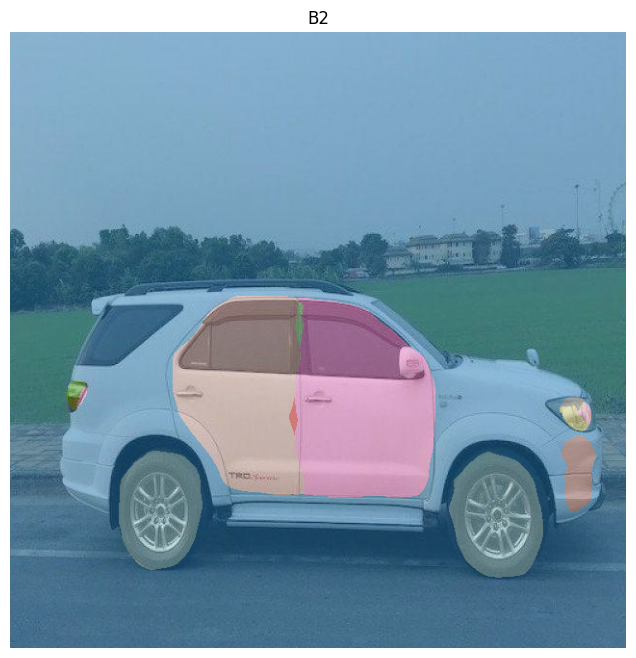

In [12]:
#Визуализировать резудьтаты
model_path = 'lightning_logs/version_0/checkpoints/last.ckpt'
model = SegformerFinetuner.load_from_checkpoint(
    model_path,
    id2label=test_dataset.id2label, 
    train_dataloader=train_dataloader,
)

model.eval()
test_image_path = "car_dataset/images/test/train124_jpg.rf.113347d65656b80c0166c14757b70064.jpg"
#'car_dataset/images/test/car4_jpg.rf.8978131a7b03be689c244641e42e1307.jpg'
test_image = cv2.imread(test_image_path)#, cv2.IMREAD_COLOR)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(test_image.astype('uint8'))
encoded_inputs = feature_extractor(image_pil, return_tensors='pt')
pixel_values = encoded_inputs.pixel_values
pixel_values = pixel_values.to(torch.device('cuda'))

with torch.no_grad():
    outputs = model(pixel_values)

    logits = outputs[0]
    predicted_mask = nn.functional.interpolate(
        logits,
        size=test_image.shape[:2],
        mode="bilinear",
        align_corners=False #Че это
    ).argmax(dim=1).squeeze().cpu().numpy()
    #По-моему она не расскарашивает + оставляет пиксели дробными (типа не 1.0, а 0.963)


# Показываем наложение
plt.figure(figsize=(8, 8))
plt.imshow(test_image)
plt.imshow(predicted_mask, alpha=0.5, cmap='tab20')
plt.title('B2')
plt.axis('off')
plt.show()